##Import Libraries

In [ ]:
!pip install cleanvision
!pip install brisque

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import plotly.express as px
from scipy.stats import skew
import statsmodels.api as sm
import numpy as np
from cleanvision import Imagelab
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from brisque import BRISQUE
import shutil
import re
import math
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

##Needed Customizations

In [ ]:
SEED = 69
ENABLE_DETERMINISM = True

import os
os.environ['PYTHONHASHSEED'] = f'{SEED}'
os.environ['TF_DETERMINISTIC_OPS'] = f'{ENABLE_DETERMINISM}'
os.environ['TF_CUDNN_DETERMINISTIC'] = f'{ENABLE_DETERMINISM}'

import random
import numpy as np
import tensorflow as tf
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

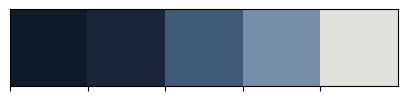

In [ ]:
dark = ["#0d1b2a","#1b263b","#415a77","#778da9","#e0e1dd"]
dark_random = ['#0d1b2a', '#415a77', '#e0e1dd', '#778da9','#1b263b']
dark_map = ListedColormap(dark)
dark_rand = sns.color_palette(dark_random)
dark_palettes = sns.color_palette(dark)
sns.palplot(dark_palettes)

##Importing Dataset from Kaggle

In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#!/bin/bash
!kaggle datasets download karimabdulnabi/fruit-classification10-class

Dataset URL: https://www.kaggle.com/datasets/karimabdulnabi/fruit-classification10-class
License(s): CC0-1.0
  0% 0.00/29.2M [00:00<?, ?B/s]
100% 29.2M/29.2M [00:00<00:00, 1.30GB/s]


In [ ]:
import zipfile

with zipfile.ZipFile("/content/fruit-classification10-class.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/data")

In [ ]:
train_dir = "/content/data/MY_data/train"
test_dir = "/content/data/MY_data/test"
predict_dir = "/content/data/MY_data/predict"

##Data (Images) Overview

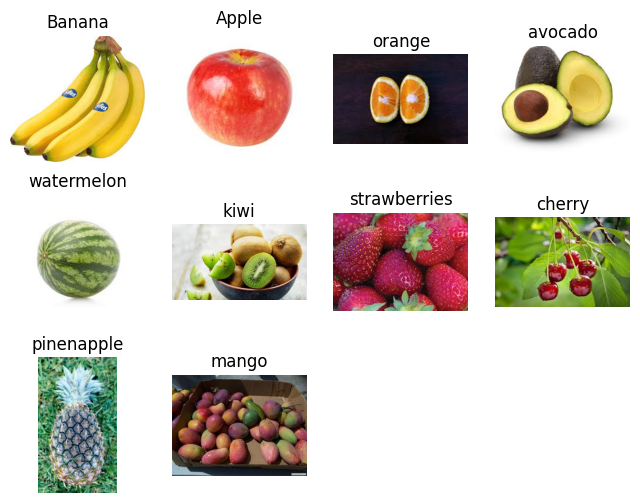

In [ ]:
classes = os.listdir(train_dir)
plt.figure(figsize=(8,6))

for i, cls in enumerate(classes):
    img_name = random.choice(os.listdir(os.path.join(train_dir, cls)))
    img_path = os.path.join(train_dir, cls, img_name)
    img = Image.open(img_path)

    plt.subplot(3, 4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()


**Images Overview Observations**
- some images are too cropped (especially bananas)
- some images contain text over the fruit
- the file oranges contain an incorrect picture of all fruits (which I think can hinder Model's performance)
- fuits themselves are sometimes far from the frame (the fruit is small and the picture has much more stuff than that fruit)
- the file watermelons contain a picture of many fruits inside a watermelon XD

In [ ]:
def count_images(data_dir):
    class_counts = {}

    for class_name in os.listdir(data_dir):
        class_dir=os.path.join(data_dir,class_name)

        if os.path.isdir(class_dir):
            num_images = len(os.listdir(class_dir))
            class_counts[class_name] = num_images

    return class_counts

train_counts = count_images(train_dir)
test_counts  = count_images(test_dir)

print("Training set distribution:")
print(train_counts)

print("\nTest set distribution:")
print(test_counts)

Training set distribution:
{'Banana': 230, 'Apple': 230, 'orange': 230, 'avocado': 230, 'watermelon': 230, 'kiwi': 230, 'strawberries': 230, 'cherry': 230, 'pinenapple': 230, 'mango': 231}

Test set distribution:
{'stawberries': 103, 'orange': 97, 'avocado': 105, 'watermelon': 105, 'apple': 89, 'banana': 106, 'kiwi': 105, 'cherry': 105, 'pinenapple': 105, 'mango': 105}


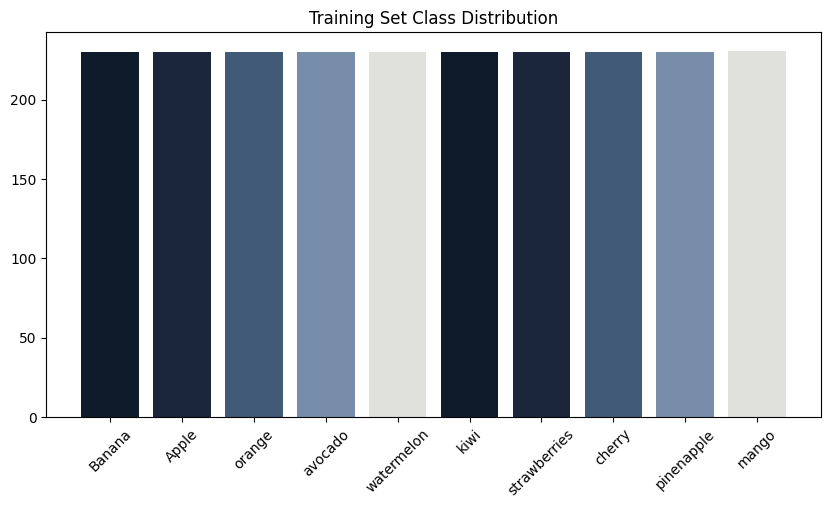

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(train_counts.keys(), train_counts.values(), color=sns.color_palette(dark_palettes, len(train_counts)))
plt.xticks(rotation=45)
plt.title("Training Set Class Distribution")
plt.show()

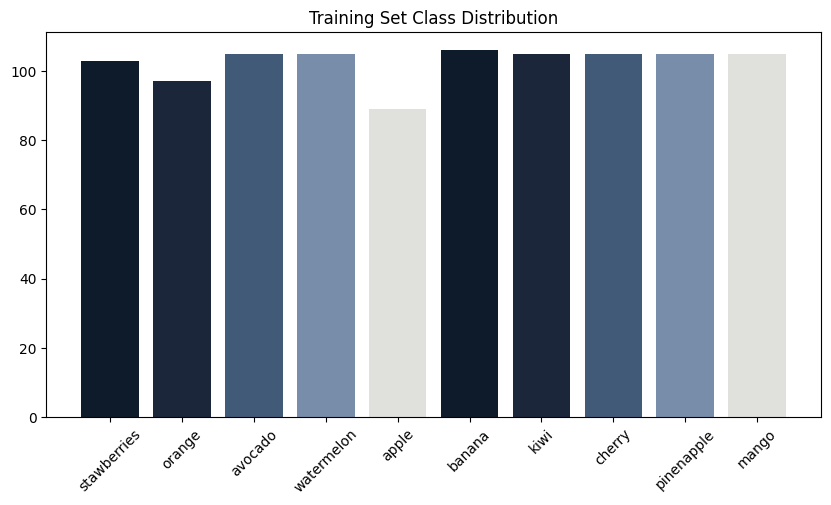

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(test_counts.keys(), test_counts.values(), color=sns.color_palette(dark_palettes, len(test_counts)))
plt.xticks(rotation=45)
plt.title("Training Set Class Distribution")
plt.show()

**Classes of Images observations**
- Classes are balanced, with one class having one more picture than the rest of the classes (mango) in training set.
- in test set (which will be used as validation set), apple class has the least amount of pictures, while banana is the most

##Attempting Image Preprocessing

In [ ]:
def check_image_sizes(data_dir, num_samples=2000):
    sizes = []

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)

        images = os.listdir(cls_path)
        sample_images = random.sample(images, min(num_samples, len(images)))

        for img_name in sample_images:
            img_path = os.path.join(cls_path, img_name)

            try:
                with Image.open(img_path) as img:
                    sizes.append(img.size)
            except:
                pass
    return sizes

sizes = check_image_sizes(train_dir)
unique_sizes = set(sizes)

print("Unique image sizes found:")
print(unique_sizes)

Unique image sizes found:
{(222, 149), (176, 286), (178, 283), (204, 247), (206, 244), (205, 246), (243, 208), (179, 282), (225, 224), (188, 269), (190, 266), (200, 252), (177, 284), (201, 251), (203, 248), (202, 249), (221, 229), (223, 226), (314, 161), (357, 141), (187, 270), (168, 299), (189, 267), (276, 183), (239, 211), (324, 156), (199, 253), (297, 169), (219, 231), (254, 198), (259, 194), (185, 272), (420, 120), (280, 180), (347, 145), (266, 190), (197, 255), (267, 189), (272, 185), (252, 200), (257, 196), (240, 180), (258, 195), (287, 176), (292, 172), (247, 204), (213, 236), (279, 181), (284, 177), (184, 273), (270, 187), (299, 168), (256, 197), (377, 133), (343, 147), (262, 192), (290, 174), (291, 173), (246, 205), (245, 206), (251, 201), (211, 238), (209, 241), (217, 233), (269, 188), (298, 169), (301, 168), (260, 194), (207, 243), (289, 175), (379, 133), (244, 207), (249, 203), (215, 235), (250, 202), (233, 216), (180, 180), (281, 180), (308, 164), (234, 215), (402, 125), (

In [ ]:
def check_image_modes(data_dir, num_samples=2000):
    modes = set()

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)
        images = os.listdir(cls_path)

        for img_name in images[:num_samples]:
            img_path = os.path.join(cls_path, img_name)

            try:
                with Image.open(img_path) as img:
                    modes.add(img.mode)
            except:
                pass
    return modes

modes = check_image_modes(train_dir)
print("Image Modes:", modes)

modes_test = check_image_modes(test_dir)
print("Image Modes in test:", modes_test)

Image Modes: {'RGB', 'P'}
Image Modes in test: {'RGB', 'P'}


In [ ]:
def check_formats(data_dir):
    formats = set()

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)

        for img_name in os.listdir(cls_path):
            ext = os.path.splitext(img_name)[1]
            formats.add(ext.lower())

    return formats

formats = check_formats(train_dir)
print("Image Formats:", formats)

formats_test = check_formats(test_dir)
print("Image Formats in test:", formats_test)

Image Formats: {'.jpeg'}
Image Formats in test: {'.jpeg'}


In [ ]:
def find_corrupted_images(data_dir):
    corrupted = []

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)

        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except:
                corrupted.append(img_path)

    return corrupted

corrupted_images = find_corrupted_images(train_dir)
print("Number of corrupted images in training set:", len(corrupted_images))

corrupted_images_test = find_corrupted_images(test_dir)
print("Number of corrupted images in testing set:", len(corrupted_images_test))

Number of corrupted images in training set: 0
Number of corrupted images in testing set: 0


**data info overview**
- almost all pictures are not of the same size
- there are two types of color modes in both training and testing set
- there are only one format, and no corrupted images in both sets
- probably will generalize (normaliza) all sizes of images to (224,224) since it's most common and better for CNN architecture

Note:

-   to attempt to find issues with data, I started searching until I found something called "Quality Score* for images. I am pretty sure that these scores are for noises only (not the text or wrong frames of pictures I found earlier in data overview)

  anyways, I found two things: BRISQUE and Cleanvision. so I will attempt to use them. this note to whoever grades my task

In [ ]:
train_imagelab = Imagelab(data_path=train_dir)

train_imagelab.find_issues()

Reading images from /content/data/MY_data/train
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing scores:   0%|          | 0/2301 [00:00<?, ?it/s]

Computing hashes:   0%|          | 0/2301 [00:00<?, ?it/s]

Issue checks completed. 81 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().


Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | near_duplicates  |           26 |
|  1 | low_information  |           13 |
|  2 | odd_size         |           11 |
|  3 | odd_aspect_ratio |           11 |
|  4 | exact_duplicates |           10 |
|  5 | dark             |            7 |
|  6 | blurry           |            3 |
|  7 | light            |            0 |
|  8 | grayscale        |            0 | 

------------------ near_duplicates images ------------------

Number of examples with this issue: 26
Examples representing most severe instances of this issue:

Set: 0


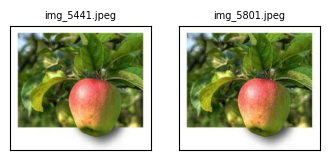

Set: 1


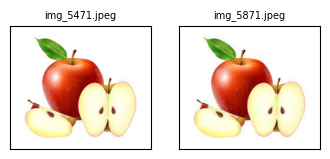

Set: 2


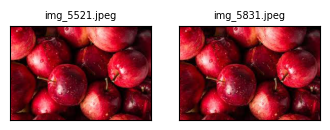

Set: 3


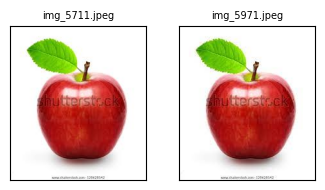

------------------ low_information images ------------------

Number of examples with this issue: 13
Examples representing most severe instances of this issue:



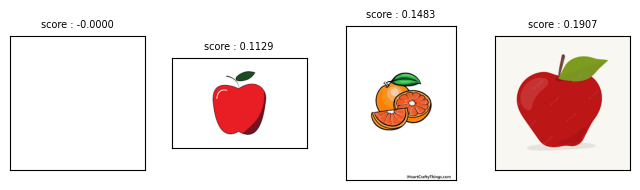

--------------------- odd_size images ----------------------

Number of examples with this issue: 11
Examples representing most severe instances of this issue:



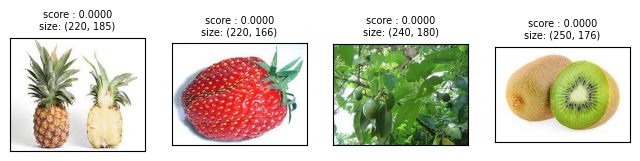

----------------- odd_aspect_ratio images ------------------

Number of examples with this issue: 11
Examples representing most severe instances of this issue:



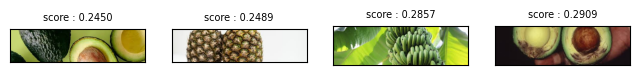

----------------- exact_duplicates images ------------------

Number of examples with this issue: 10
Examples representing most severe instances of this issue:

Set: 0


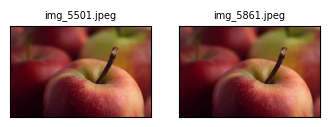

Set: 1


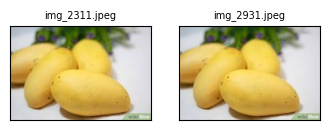

Set: 2


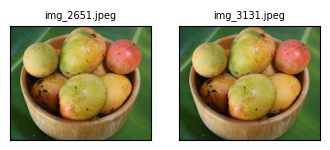

Set: 3


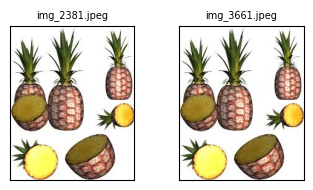

----------------------- dark images ------------------------

Number of examples with this issue: 7
Examples representing most severe instances of this issue:



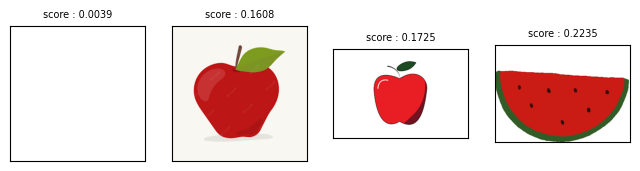

---------------------- blurry images -----------------------

Number of examples with this issue: 3
Examples representing most severe instances of this issue:



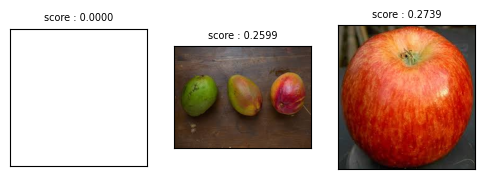

In [ ]:
train_imagelab.report()

In [ ]:
def calculate_brisque_scores(data_dir):
    quality_scores = {}
    brisque = BRISQUE()

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)


        images = os.listdir(cls_path)

        for img_name in images:
            if img_name.lower().endswith('.jpeg'):
                img_path = os.path.join(cls_path, img_name)

                try:
                    with Image.open(img_path) as img:
                        img = img.convert('RGB')
                        img_array = np.asarray(img)
                        score = brisque.score(img=img_array)

                        quality_scores[f"{cls}/{img_name}"] = score
                        #print(f"{cls}/{img_name}: {score}")

                except Exception as e:
                    print(f"Error with {cls}/{img_name}: {e}")
                    #print(cls_path)


    return quality_scores


quality_scores = calculate_brisque_scores(train_dir)

threshold = 50
low_quality = {img: score for img, score in quality_scores.items() if score > threshold}

print(f"\nTotal images processed: {len(quality_scores)}")
print(f"Low quality images (> {threshold}): {len(low_quality)}")

scores = list(quality_scores.values())
print(f"\nScore distribution:")
print(f"  Min: {min(scores):.2f}")
print(f"  Max: {max(scores):.2f}")
print(f"  Mean: {sum(scores)/len(scores):.2f}")


Total images processed: 1975
Low quality images (> 50): 0

Score distribution:
  Min: -10.98
  Max: 49.90
  Mean: 20.57


Total images processed: 2285

Low quality images (> 50): 256

Score distribution:

  Min: -10.98

  Max: 155.84

  Mean: 25.61

I'll plot quality score distribution (the lower the score the higher the quality)

In [ ]:
scores = list(quality_scores.values())

percentiles = {
    '3th': np.percentile(scores, 3),
    '25th': np.percentile(scores, 25),
    '50th (median)': np.percentile(scores, 50),
    '75th': np.percentile(scores, 75),
    '97th': np.percentile(scores, 97)
}

print("Score percentiles:")
for name, value in percentiles.items():
    print(f"  {name}: {value:.2f}")

Score percentiles:
  3th: 1.33
  25th: 12.16
  50th (median): 18.95
  75th: 27.95
  97th: 45.54


Text(0.5, 1.0, 'Score Distribution')

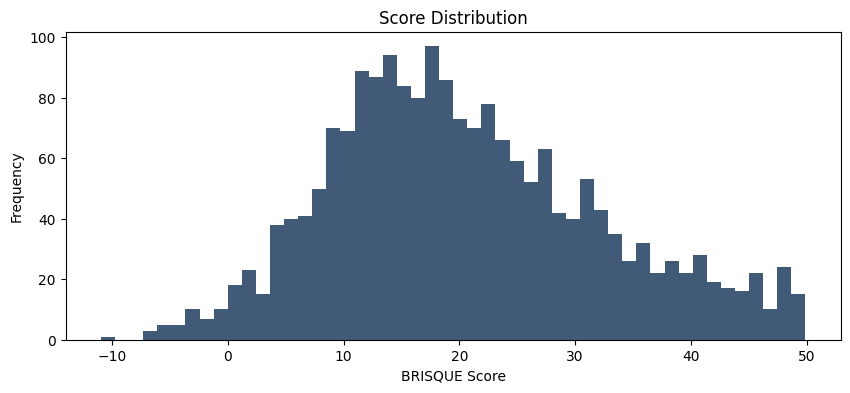

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(scores, bins=50, color=dark_palettes[2])
plt.xlabel('BRISQUE Score')
plt.ylabel('Frequency')
plt.title('Score Distribution')

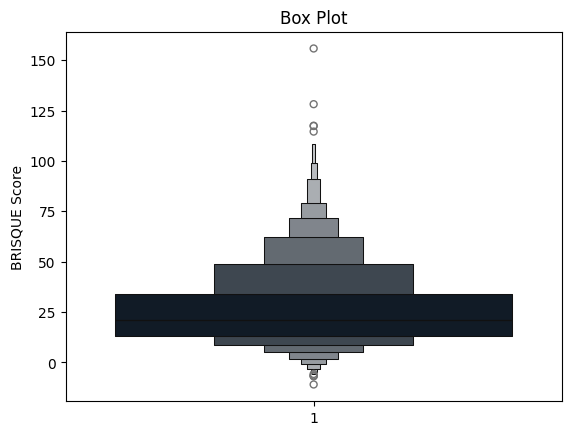

In [ ]:
sns.boxenplot(x=1, y=scores, palette=dark_palettes)
plt.ylabel('BRISQUE Score')
plt.title('Box Plot')
plt.show()

**Box plot and Histogram for Quality Scores observation**
- best score to start removing from (remember: the lower the score the better the quality of picture) is probably 50

In [ ]:
#fixing

imagelab_df = train_imagelab.issues

In [ ]:
imagelab_df.head()

,odd_size_score,is_odd_size_issue,odd_aspect_ratio_score,is_odd_aspect_ratio_issue,low_information_score,is_low_information_issue,light_score,is_light_issue,grayscale_score,is_grayscale_issue,dark_score,is_dark_issue,blurry_score,is_blurry_issue,exact_duplicates_score,is_exact_duplicates_issue,near_duplicates_score,is_near_duplicates_issue
/content/data/MY_data/train/Apple/images.jpeg,0.928571,False,0.665455,False,0.734466,False,0.996078,False,1,False,0.912813,False,0.792901,False,1.0,False,1.0,False
/content/data/MY_data/train/Apple/img_01.jpeg,0.928571,False,0.665455,False,0.814881,False,0.988596,False,1,False,0.792174,False,0.549125,False,1.0,False,1.0,False
/content/data/MY_data/train/Apple/img_1001.jpeg,0.860090,False,0.749035,False,0.924095,False,0.864023,False,1,False,0.965595,False,0.463515,False,1.0,False,1.0,False
/content/data/MY_data/train/Apple/img_101.jpeg,0.860090,False,0.749035,False,0.731368,False,0.524529,False,1,False,1.000000,False,0.932232,False,1.0,False,1.0,False
/content/data/MY_data/train/Apple/img_1071.jpeg,0.000000,True,1.000000,False,0.910882,False,0.753240,False,1,False,0.861690,False,0.487652,False,1.0,False,1.0,False


In [ ]:
print(imagelab_df[imagelab_df['is_blurry_issue'] == True].index.tolist())

['/content/data/MY_data/train/Apple/img_721.jpeg', '/content/data/MY_data/train/mango/img_3421.jpeg', '/content/data/MY_data/train/orange/img_2731.jpeg']


In [ ]:
imagelab_df['is_blurry_issue'].dtype

dtype('bool')

In [ ]:
boolean_issues = ['is_odd_size_issue', 'is_odd_aspect_ratio_issue', 'is_low_information_issue', 'is_light_issue', 'is_grayscale_issue',
                  'is_dark_issue', 'is_blurry_issue', 'is_exact_duplicates_issue', 'is_near_duplicates_issue']

issues_counter = 0   #just to make sure

for col in boolean_issues:
    for issue_path in imagelab_df[imagelab_df[col] == True].index.tolist():
      try:
        os.remove(issue_path)
        issues_counter += 1
      except:
        pass


print("images removed: ", issues_counter)

images removed:  73


In [ ]:
score_counter = 0   #just to make sure

for key, val in quality_scores.items():
  if val > 50:
      try:
        full_path = "/content/data/MY_data/train/" + key
        os.remove(full_path)
        score_counter += 1
      except:
        pass


score_counter

253

In [ ]:
modes_cleaned = check_image_modes(train_dir)
print("Image Modes:", modes_cleaned)

modes_test = check_image_modes(test_dir)
print("Image Modes in test:", modes_test)

Image Modes: {'RGB'}
Image Modes in test: {'RGB', 'P'}


In [ ]:
for cls in os.listdir(test_dir):
    cls_path = os.path.join(test_dir, cls)

    images = os.listdir(cls_path)

    for img_name in images:

         img_path = os.path.join(cls_path, img_name)
         with Image.open(img_path) as img:
          if img.mode == 'P':
            print(img_path)
            img = img.convert('RGB')
            img.save(img_path)

/content/data/MY_data/test/orange/img_771.jpeg
/content/data/MY_data/test/orange/img_1631.jpeg
/content/data/MY_data/test/avocado/img_591.jpeg
/content/data/MY_data/test/apple/img_271.jpeg
/content/data/MY_data/test/apple/img_101.jpeg
/content/data/MY_data/test/apple/img_441.jpeg
/content/data/MY_data/test/banana/img_371.jpeg
/content/data/MY_data/test/cherry/img_561.jpeg
/content/data/MY_data/test/pinenapple/img_141.jpeg
/content/data/MY_data/test/pinenapple/img_761.jpeg


In [ ]:
for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)

    images = os.listdir(cls_path)

    for img_name in images:

         img_path = os.path.join(cls_path, img_name)
         with Image.open(img_path) as img:
          if img.mode == 'P':
            print(img_path)
            img = img.convert('RGB')
            img.save(img_path)

In [ ]:
modes_cleaned = check_image_modes(train_dir)
print("Image Modes:", modes_cleaned)

modes_test = check_image_modes(test_dir)
print("Image Modes in test:", modes_test)

Image Modes: {'RGB'}
Image Modes in test: {'RGB'}


In [ ]:
#last check

check_imagelab = Imagelab(data_path=train_dir)

check_imagelab.find_issues()

check_imagelab.report()

Reading images from /content/data/MY_data/train
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing scores:   0%|          | 0/1975 [00:00<?, ?it/s]

Computing hashes:   0%|          | 0/1975 [00:00<?, ?it/s]

Issue checks completed. 0 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | dark             |            0 |
|  1 | light            |            0 |
|  2 | odd_aspect_ratio |            0 |
|  3 | low_information  |            0 |
|  4 | blurry           |            0 |
|  5 | grayscale        |            0 |
|  6 | odd_size         |            0 |
|  7 | exact_duplicates |            0 |
|  8 | near_duplicates  |            0 | 



Yaaaaaaaaaaaaaaayyyy :D

I didn't think this thing will work

##Model Building and Evaluation

In [ ]:
#dividing images (important)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1975 files belonging to 10 classes.
Using 1580 files for training.
Found 1975 files belonging to 10 classes.
Using 395 files for validation.
Found 1025 files belonging to 10 classes.


In [ ]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['Apple', 'Banana', 'avocado', 'cherry', 'kiwi', 'mango', 'orange', 'pinenapple', 'strawberries', 'watermelon']


In [ ]:
data_augmentation = keras.Sequential([
    #layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
def build_model(input_shape=(224, 224,3), num_classes=10):

    inputs = layers.Input(shape=input_shape)

    # Normalize pixels
    inputs = layers.Rescaling(1./255)(inputs)

    x = data_augmentation(inputs)

    # CNN
    x = layers.Conv2D(32, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(32, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    #x = layers.Conv2D(64, (3,3), padding='same')(x)
    #x = layers.BatchNormalization()(x)
    #x = layers.ReLU()(x)
    #x = layers.MaxPooling2D()(x)

    #x = layers.Conv2D(256, (3,3), padding='same')(x)
    #x = layers.BatchNormalization()(x)
    #x = layers.ReLU()(x)
    #x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


model = build_model(num_classes=10)
model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_152CLONE           │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_24 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_25 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_26 (ReLU)                 │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,802 (116.41 KB)

 Trainable params: 29,546 (115.41 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam
from keras.optimizers import Nadam
from tensorflow.keras.optimizers import AdamW

model.compile(
    optimizer = AdamW(learning_rate=0.001,weight_decay=0.004,  clipnorm=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    )
    #tf.keras.callbacks.ReduceLROnPlateau(
    #   factor=0.5,
    #    patience=5
    #)
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 192ms/step - accuracy: 0.2532 - loss: 2.1567 - val_accuracy: 0.1924 - val_loss: 2.8947
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.3139 - loss: 1.8818 - val_accuracy: 0.2430 - val_loss: 1.9960
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.3380 - loss: 1.7877 - val_accuracy: 0.3089 - val_loss: 1.8628
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.3582 - loss: 1.7507 - val_accuracy: 0.3595 - val_loss: 1.7960
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.3753 - loss: 1.7073 - val_accuracy: 0.4354 - val_loss: 1.5782
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - accuracy: 0.3816 - loss: 1.6827 - val_accuracy: 0.4532 - val_loss: 1.4966
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.4063 - loss: 1.6526 - val_accuracy: 0.4354 - val_loss: 1.5254
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - accuracy: 0.4228 - loss: 1.6307 - val_accuracy: 0

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.4605 - loss: 1.6588
Test Accuracy: 0.46048781275749207


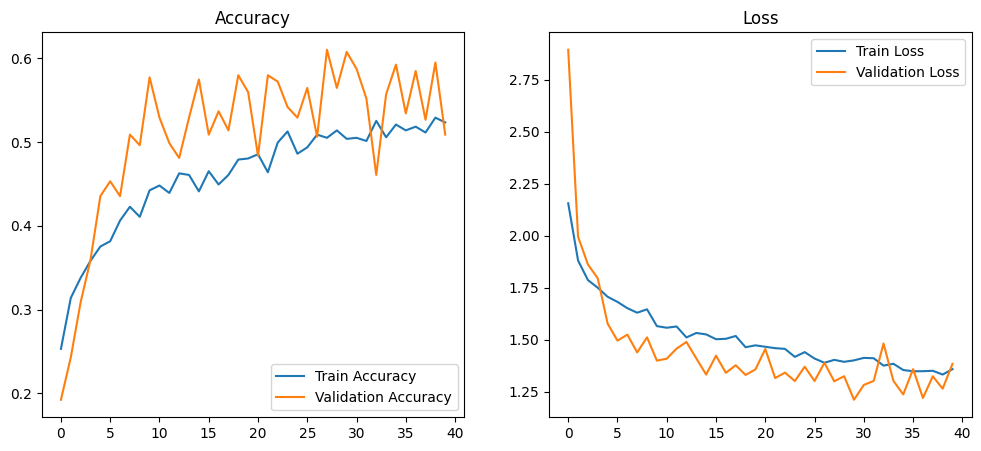

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(12,5), edgecolor=dark_palettes[1])

plt.subplot(1,2,1)
plt.plot(acc,label="Train Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(loss,label="Train Loss")
plt.plot(val_loss,label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()

I tried so much with this thing

I give up